# Big Data & Analitycs

## Act 2 - Aplicación y análisis de técnicas de inteligencia artificial en entornos IoT

**Pregunta 1: A modo de introducción, describe brevemente y con tus propias palabras en qué consiste el mantenimiento predictivo y qué ventajas aporta en el contexto de la Industria 4.0.**

El concepto de mantenimiento predictivo surge del principio de planificar los mantenimientos teniendo en cuenta el estado real del equipo o maquina mediante el monitoreo en tiempo real de parametros caracteristicos.
En contraparte con el mantenimiento correctivo, que se ejecuta luego de que surja la falla, y del mantenimiento preventivo, que se ejecuta cada determinado ciclo independientemente del estado actual del equipo, el enfoque predictivo optimiza los recursos y disminuye los costes puesto que solo se interviene cuando es necesario.
 Es una aplicacion natural del paradigma de Industria 4.0, la obtension de datos en tiempo real, el procesamiento de los grandes volumenes de datos generados y su posterior tratamiento con algoritmos de inteligencia artificial y aprendizaje automatico son los responsables directos de la predicción del estado de la maquina.

 **Pregunta 2: Justifica la monitorización en tiempo real de las turbinas de avión.**

 La aparicion de una falla en un turbina de avion puede resultar catastrofica si la misma se genera durante un vuelo siendo incompatible, por lo cual la cantidad de mantenimientos correctivos son limitados. Por otra parte mantener parado un avion en un hangar para mantenimiento resulta economicamente poco redituable. Por lo tanto la necesidad de ejecutar los mantenimientos de la forma mas eficiente posible justifica la monitorizacion en tiempo real de parametros con el fin de implementar mantenimiento predictivo y determina la vida util del motor.

**Pregunta 3: Describe el dataset: ¿Cuántos ficheros contiene? ¿Qué propósito tiene cada uno de ellos? ¿Cuántos sensores proporcionan información y en cuántas configuraciones? Incluye el tipo de variables que ofrece el conjunto de datos, así como la variable de respuesta**

El dataset contiene tres ficheros:
'PM_train'
'PM_test'
'PM_truth'

El archivo PM_train contiene para 100 motores distintos un snapshot de valores, 21 sensores y 3 parametros de operacion, por ciclo de una serie temporal que ocupa desde inicio hasta que se produce el fin de la vida util.
El archivo PM_test contiene las mismas mediciones, 21 sensores y 3 seteos de operacion, pero el ultimo ciclo registrado es aleatorio, es decir no llega al fallo.
Finalmente el archivo PM_truth es en relacion al archivo PM_test el calculo del RUL (rest of util life) conforme el ultimo ciclo registrado.

https://www.kaggle.com/datasets/behrad3d/nasa-cmaps/data






In [66]:
# Carga de librerías necesarias
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix,accuracy_score

from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Activation
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

## Datasets

### Dataset > TRAIN

In [67]:
#Cargamos los dataset desde github

dataset_train = pd.read_csv('https://raw.githubusercontent.com/jmturchi/DataSet_BDA_Act2/refs/heads/main/PM_train', sep=' ', header=None).drop([26,27],axis=1)
col_names = ['id','cycle','setting1','setting2','setting3','s1','s2','s3','s4','s5','s6','s7','s8','s9','s10','s11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']
dataset_train.columns=col_names
print('Dimensiones del conjunto de datos de entrenamiento: ',dataset_train.shape)
dataset_train.head()


Dimensiones del conjunto de datos de entrenamiento:  (20631, 26)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Dataset > TEST

In [68]:
dataset_test = pd.read_csv('https://raw.githubusercontent.com/jmturchi/DataSet_BDA_Act2/refs/heads/main/PM_test', sep=' ', header=None).drop([26,27],axis=1)
col_names = ['id','cycle','setting1','setting2','setting3','s1','s2','s3','s4','s5','s6','s7','s8','s9','s10','s11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']
dataset_test.columns=col_names
print('Dimensiones del conjunto de datos de evaluación: ',dataset_test.shape)
dataset_test.head()

Dimensiones del conjunto de datos de evaluación:  (13096, 26)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


### Dataset > TRUTH

In [69]:
pm_truth= pd.read_csv('https://raw.githubusercontent.com/jmturchi/DataSet_BDA_Act2/refs/heads/main/PM_truth', sep=' ', header=None).drop([1],axis=1)
pm_truth.columns=['more']
pm_truth['id']=pm_truth.index+1
print('Dimensiones de los datos target del dataset: ' ,pm_truth.shape)
pm_truth.head()


Dimensiones de los datos target del dataset:  (100, 2)


,more,id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


In [70]:
# generamos la columna máxima para el resto de los datos
rul = pd.DataFrame(dataset_test.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max']
print('Dimensión de los datos máximos: ', rul.shape)
rul.head()


Dimensión de los datos máximos:  (100, 2)


,id,max
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


In [71]:
# generamos la columna RTF (Remain To Failure) con el maximo para los fallos
pm_truth['rtf']=pm_truth['more'] + rul['max']
print('Dimesiones de los datos target del dataset: ', pm_truth.shape)
pm_truth.head()


Dimesiones de los datos target del dataset:  (100, 3)


,more,id,rtf
0,112,1,143
1,98,2,147
2,69,3,195
3,82,4,188
4,91,5,189


In [72]:
# realizamos un merge de los dataset truth y test
pm_truth.drop('more', axis=1, inplace=True)
#conmbinamos los dataset test y truth mediante el id
dataset_test=dataset_test.merge(pm_truth,on=['id'],how='left')

# El valor de TTF (Time To Failure) lo calculamos como el RTF (Remain To Failure) - el número de ciclos actual:
dataset_test['ttf']=dataset_test['rtf'] - dataset_test['cycle']
dataset_test.drop('rtf', axis=1, inplace=True)
print('Dimensión del conjunto de datos de evaluación tras la unión: ', dataset_test.shape)
dataset_test.head()


Dimensión del conjunto de datos de evaluación tras la unión:  (13096, 27)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,ttf
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


In [73]:
#El valor TTF se añade al dataset_train
# Lo calculamos como la resta del valor maximo de ciclos - el numero de ciclo
# actual:

dataset_train['ttf'] = dataset_train.groupby(['id'])['cycle'].transform(max)-dataset_train['cycle']
print('Dimensión del conjunto de datos de entrenamiento: ', dataset_train.shape)
dataset_train.head()


Dimensión del conjunto de datos de entrenamiento:  (20631, 27)


/tmp/ipykernel_9822/2063800991.py:5: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  dataset_train['ttf'] = dataset_train.groupby(['id'])['cycle'].transform(max)-dataset_train['cycle']


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,ttf
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [74]:
# Para los dataframes de entrenamiento y evaluación crearemos una nueva columna "label_bc" que se tomará los siguientes valores:
#    - 1 Si el número de ciclos restantes es menor o igual a un periodo.
#    - 0 Si el número de ciclos restantes es menor o igual a un periodo.
# Asignamos un valor de 30 ciclos a este periodo.

#Creamos dos copias del conjunto de datos
df_train=dataset_train.copy()
df_test=dataset_test.copy()
#Numero de ciclos del periodo
period=30

#Creamos la columna label_bc
df_train['label_bc'] = df_train['ttf'].apply(lambda x: 1 if x <= period else 0)
df_test['label_bc'] = df_test['ttf'].apply(lambda x: 1 if x <= period else 0)
print('Dimension del DF (dataframe) de train: ', df_train.shape)
df_train.head()





Dimension del DF (dataframe) de train:  (20631, 28)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,ttf,label_bc
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,0


In [75]:
print('Dimension del DF (dataframe) de test: ', df_test.shape)
df_train.head()


Dimension del DF (dataframe) de test:  (13096, 28)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,ttf,label_bc
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,0


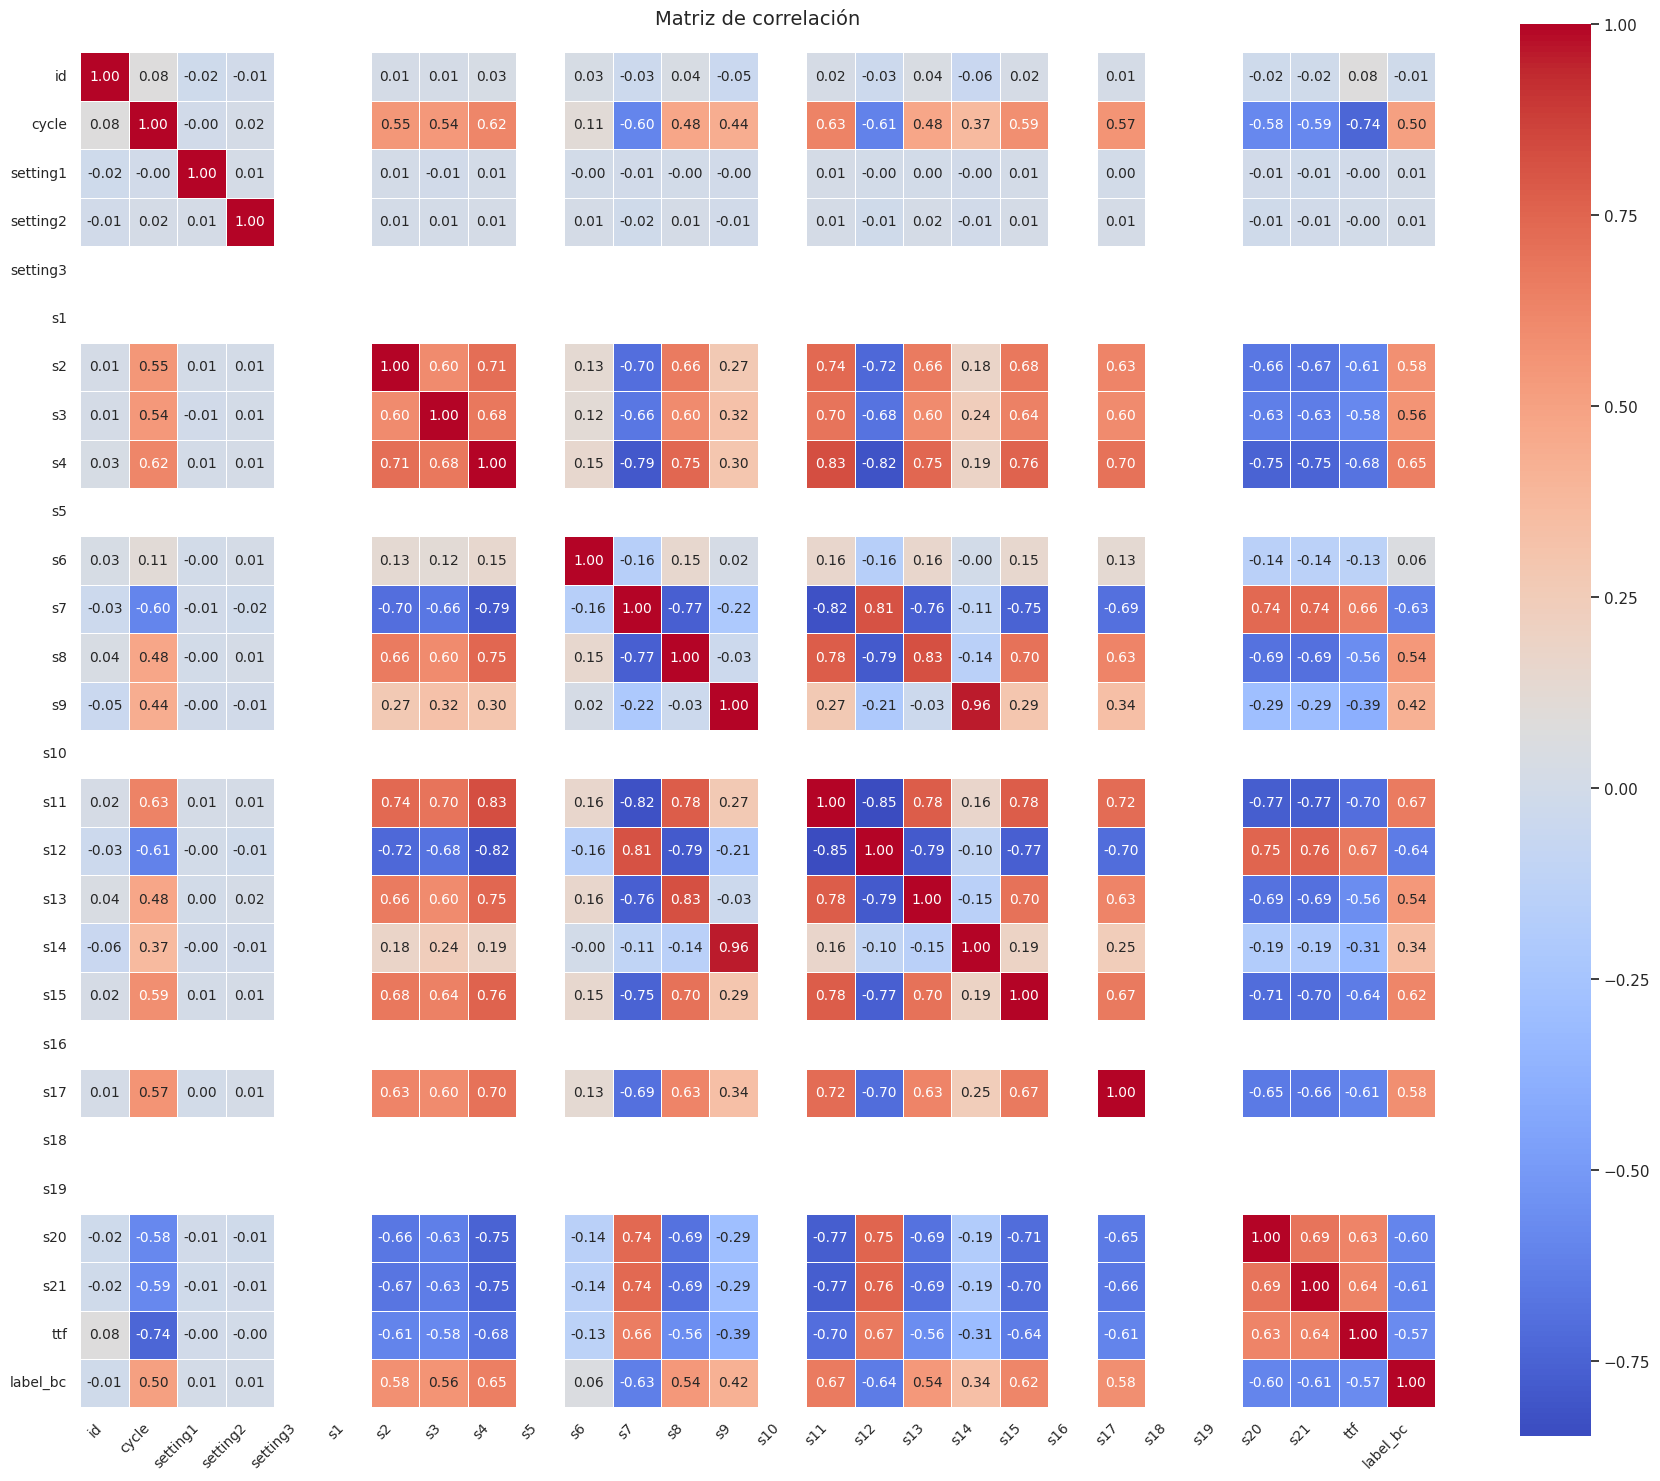

In [76]:
# Calculo la correlación entre las variables
corr = df_train.corr()
#Representamos la matriz de correalcion en forma de mapa de calor:

#configuramos el grafico
plt.figure(figsize=(18,18)) #Ajusto tamano de grafico
sns.set(style='white') #Estilo limpio para el fondo
#Mapa de calor de la matriz de correlación:
sns.heatmap(corr,                         #Matriz de correlacion
            annot = True,                 #Mostrar los valores de la correlacion
            fmt=".2f",                    #Formato de los numeros 2 decim
            cmap="coolwarm",              #Paleta de colores
            square=True,                  #Cuadricula con celdas cuadradas
            cbar_kws={"shrink": 0.8},     #Ajust el tamano de la barra de colores
            linewidths=0.5,               #Lineas entre celdas
            annot_kws={"size": 10},       #Tamano de las anotaciones
            )
plt.title("Matriz de correlación", fontsize = 14, pad=20)
plt.xticks(fontsize=10, rotation=45, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()


**Pregunta 4: ¿para qué han servido los diferentes pasos llevados a cabo en este apartado «Carga del archivo TRUTH que contiene como datos el target del dataset»?**

Nos sirvieron para calcular el TTF (time to failure), es decir el tiempo de vida util y la columna de fallo inminente label_bc (menos de 30 ciclos para el TTF), esto nos da cuenta que necesitaremos sacar de servicio el motor reservarlo para mantenimineto. Finalmente se genera una matriz de correlacion con mapa de calor, valores cercanos a +1 nos indica una fuerte correlacion positiva si aumenta el sensor aumenta el ttf o el label_bc por el contrario valores cercanos a -1 un correlacion fuerte inversa por ultimo valores entorno a cero nos hablan de una correlacion debil  


**Pregunta 5: ¿Qué conclusiones más relevantes se pueden extraer observando la matriz de correlación?**

La matriz muestra la relación lineal entre las diferentes variables, valores cercanos a +1 nos indica una fuerte relación lineal positiva, es decir si una variable aumenta la otra variable aumentará, mientras que valores cercanos a -1 nos indica una fuerte relación negativa, si una aumenta la otra disminuirá su valor. Finalmente, valores próximos a cero nos indica una débil o inexistente relación lineal.

In [77]:
# Eliminamos las variables que no serán de utilidad para el PCA:
dataset_train_pca = df_train.drop(['id','cycle','setting1','setting2','setting3','ttf','label_bc'],axis=1)

# Generamos otro conjunto de datos con las variables excluidas del PCA (id, configuraciones, variable objetivo):
dataset_train_no_pca = df_train.drop(['setting3','s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17',
's18', 's19', 's20', 's21'],axis=1)


In [78]:
# Importamos la librería para la estandarización:
from sklearn.preprocessing import StandardScaler
# Realizamos la estandarización, resultando x nuestro conjunto de datos de entrenamiento estandarizados:
x = StandardScaler().fit_transform(dataset_train_pca)

# Mostramos la media y desviación estándar (globales) de los datos estandarizados:
print(f"µ = ", np.mean(x))
print(f"σ = ", np.std(x))


µ =  -2.4960035213266096e-13
σ =  0.8451542547285167


In [79]:
# Renombramos:
feat_cols = ['Feature'+str(i) for i in range(x.shape[1])]
# Creamos un nuevo dataframe con los datos normalizados:
norm_df = pd.DataFrame(x,columns=feat_cols)

# Mostramos los datos:
norm_df.head()


,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,...,Feature11,Feature12,Feature13,Feature14,Feature15,Feature16,Feature17,Feature18,Feature19,Feature20
0,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,0.141683,1.121141,-0.516338,-0.862813,0.0,...,0.334262,-1.058890,-0.269071,-0.603816,-1.387779e-17,-0.781710,0.0,0.0,1.348493,1.194427
1,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,0.141683,0.431930,-0.798093,-0.958818,0.0,...,1.174899,-0.363646,-0.642845,-0.275852,-1.387779e-17,-0.781710,0.0,0.0,1.016528,1.236922
2,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,0.141683,1.008155,-0.234584,-0.557139,0.0,...,1.364721,-0.919841,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.0,0.0,0.739891,0.503423
3,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,0.141683,1.222827,0.188048,-0.713826,0.0,...,1.961302,-0.224597,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.0,0.0,0.352598,0.777792
4,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,0.141683,0.714393,-0.516338,-0.457059,0.0,...,1.052871,-0.780793,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.0,0.0,0.463253,1.059552


**Pregunta 6: ¿Qué representa la tabla anterior? ¿Qué significado tiene dentro del algoritmo PCA?**  

Representa los valores de datos estandarizados. Dado que cada medicion tiene su propia escala la dispersion de los datos puede producir que al aplicar PCA una variable cobre mayor peso debido a la escala. Para evitar esto se normalizan los datos de manera que tengan una media cero y desviacion 1 al aplicar la trasnformacion. Esto nos permite independizarnos de la escala y que todas las caracteristicas tenga pesos comparables. En criollo ahora todos los valores van a estar en torno al eje entonces voy a poder comparar las distancias entre caracteristicas y modelar la representatividad con PCA




In [101]:
# Calculamos la covarianza:
cov_x = np.cov(x.T)

# Eigenvalues y eigenvectors
eig_vals, eig_vecs = np.linalg.eig(cov_x)

# Listado de eigenvalues y eigenvectors:
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]

# Listado ordenada de los pares de eigenvalues y eigenvectors en función de los eigenvalues:
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Mostramos los autovalores:
print('Autovalores ordenados:')
for i in eig_pairs:
  print(i[0])


Autovalores ordenados:
9.026834847212681
2.098642321494199
0.9664790535206516
0.4139520934296981
0.368301408451432
0.34833307191389323
0.30612465091254565
0.2898043172945272
0.2554174802622778
0.2061962334797201
0.19602838643885453
0.17658931901159555
0.17255633364765444
0.14619238956920277
0.029275189822557834
0.0
0.0
0.0
0.0
0.0
0.0


**Pregunta 7: ¿Qué significado tienen los autovalores obtenidos?**

Con las variables normalizadas calculamos la matriz de covarianza y después los autovectores y autovalores. Los autovectores con los autovalores más altos representan la direccion con mayor variabilidad del conjunto de datos y por lo tanto serán las componentes que concentran mayor información representativa.

In [81]:
# Matriz de proyección de los autovectores:
matrix_w = np.hstack((eig_pairs[0][1].reshape(21,1),
                      eig_pairs[1][1].reshape(21,1),
                      eig_pairs[2][1].reshape(21,1),
                      eig_pairs[3][1].reshape(21,1),
                      eig_pairs[4][1].reshape(21,1),
                      eig_pairs[5][1].reshape(21,1),
                      eig_pairs[6][1].reshape(21,1),
                      eig_pairs[7][1].reshape(21,1)))

# Visualizamos la matriz forzando que cada fila se muestre en una línea:
print('Matriz de Proyección:\n', np.array2string(matrix_w, max_line_width=np.inf))

# Construimos la matriz de datos de dimensiones reducidas en función de la selección de los autovalres:
Y = x.dot(matrix_w)
print('Tamaño de Y: ', Y.shape)
print('Matriz Y:\n', np.array2string(Y, max_line_width=np.inf))


Matriz de Proyección:
 [[ 0.          0.          0.          0.          0.          0.          0.          0.        ]
 [-0.27274481  0.01828501 -0.02193832  0.18985107  0.55520692  0.73623472 -0.07569523  0.09175744]
 [-0.2596079   0.07736212 -0.03074191 -0.93397407 -0.08059956  0.1666274  -0.04767504  0.05545754]
 [-0.30058958  0.01047153 -0.01780016  0.03529215  0.03126277 -0.0930184  -0.01615535 -0.06757603]
 [ 0.          0.          0.          0.          0.          0.          0.          0.        ]
 [-0.06234603 -0.04784759  0.99661875 -0.0171976   0.00179873  0.00954941  0.00450775  0.01000594]
 [ 0.29785673  0.05160072  0.01637791 -0.02923834  0.01037273  0.09243643 -0.01346307  0.05931796]
 [-0.28127596 -0.24317902 -0.03189912  0.02097231 -0.00319922 -0.04396233  0.01467761 -0.06702373]
 [-0.10534846  0.64336949  0.02628801  0.04601634  0.04199692 -0.05635896  0.01667691 -0.03972091]
 [ 0.          0.          0.          0.          0.          0.          0.         

▸ Pregunta 8: ¿Qué significado tiene la matriz de proyección? ¿Qué representa la nueva matriz Y?

La matriz de proyeccion es el conjunto de subespacios donde se deben proyectar los datos (es decir las direcciones de los nuevos ejes)
Mientras que la matriz Y representa el conjunto de datos pero proyectado sobre los sub espacios definidos por los k autovectores/autovalores mas representativos.

In [82]:
# Preparamos los datos PCA:
pca_imp_df = pd.DataFrame(data = Y, columns = ['PC 1', 'PC 2',
'PC 3', 'PC 4', 'PC 5', 'PC 6', 'PC 7', 'PC 8'])

# Mostramos los datos:
pca_imp_df.head()


,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8
0,2.944902,-0.452747,0.300691,-0.824244,-0.629020,-0.344302,0.032812,-0.635351
1,2.360407,-0.795862,0.248736,-0.961509,-0.285420,-0.022143,-0.303058,-0.648289
2,2.979360,-0.549591,0.290127,-0.603968,1.100258,-0.457617,0.230811,-0.106652
3,3.384948,-0.841757,0.305124,0.404573,0.052269,0.126706,-0.112252,1.127880
4,2.422708,-0.377598,0.289617,0.716113,-0.360137,0.072907,-0.494492,-0.223097


In [83]:
# Unimos los datos anteriores al dataset que incluye las configuraciones:
dataset_train_no_pca= dataset_train_no_pca.join(pca_imp_df,lsuffix='_caller', rsuffix='_other')

# Mostramos los datos:
dataset_train_no_pca


,id,cycle,setting1,setting2,ttf,label_bc,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8
0,1,1,-0.0007,-0.0004,191,0,2.944902,-0.452747,0.300691,-0.824244,-0.629020,-0.344302,0.032812,-0.635351
1,1,2,0.0019,-0.0003,190,0,2.360407,-0.795862,0.248736,-0.961509,-0.285420,-0.022143,-0.303058,-0.648289
2,1,3,-0.0043,0.0003,189,0,2.979360,-0.549591,0.290127,-0.603968,1.100258,-0.457617,0.230811,-0.106652
3,1,4,0.0007,0.0000,188,0,3.384948,-0.841757,0.305124,0.404573,0.052269,0.126706,-0.112252,1.127880
4,1,5,-0.0019,-0.0002,187,0,2.422708,-0.377598,0.289617,0.716113,-0.360137,0.072907,-0.494492,-0.223097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,4,1,-6.871941,-0.925121,-0.329168,0.589507,-0.607422,-0.047239,0.908671,0.700249
20627,100,197,-0.0016,-0.0005,3,1,-7.019167,-1.012647,-0.350161,-0.651775,0.436064,-0.562278,-1.106574,0.204556
20628,100,198,0.0004,0.0000,2,1,-7.999870,-0.725111,-0.385854,0.253698,-1.171454,-0.334683,0.771711,-0.336670
20629,100,199,-0.0011,0.0003,1,1,-7.741249,-0.771858,-0.371672,-0.716008,0.203098,-1.400807,-0.426351,-0.073903


In [84]:
# Eliminamos las variables que no son de utilidad para el PCA:
dataset_test_pca = df_test.drop(['id','cycle','setting1','setting2','setting3','ttf'
,'label_bc'],axis=1)

# Generamos otro conjunto de datos con las variables excluidas del PCA (id, configuraciones, variable objetivo):
dataset_test_no_pca = df_test.drop(['setting3','s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17',
's18', 's19', 's20', 's21'],axis=1)


In [85]:
# Importamos la librería para la estandarización:
from sklearn.preprocessing import StandardScaler
# Realizamos la estandarización, resultando x nuestro conjunto de datos de entrenamiento estandarizados:
x2 = StandardScaler().fit_transform(dataset_test_pca)

# Mostramos la media y desviación estándar (globales) de los datos estandarizados:
print(f"µ = ", np.mean(x2))
print(f"σ = ", np.std(x2))


µ =  6.608252066971411e-14
σ =  0.8451542547285166


**Pregunta 9: ¿Qué significado tienen los valores obtenidos por este último comando?**

La media representa el punto central de la nube de puntos en este caso el origen
Mientras que el desvio estandar nos indica la dispersion en relacion a dicho punto.



In [86]:
# Renombramos:
feat_cols2 = ['Feature'+str(i) for i in range(x2.shape[1])]
# Creamos un nuevo dataframe con los datos normalizados:
norm2_df = pd.DataFrame(x2,columns=feat_cols2)

# Mostramos los datos:
norm2_df.head()


,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,...,Feature11,Feature12,Feature13,Feature14,Feature15,Feature16,Feature17,Feature18,Feature19,Feature20
0,0.0,1.359276,-0.561495,-0.975674,-1.776357e-15,0.17566,0.209138,-0.539078,-0.720312,-2.220446e-16,...,-0.049542,-0.720590,-1.315031,-0.711659,-1.040834e-17,-0.463406,0.0,0.0,-0.229408,0.448866
1,0.0,-1.908502,0.070116,-1.392836,-1.776357e-15,0.17566,1.603612,-1.061366,-0.348673,-2.220446e-16,...,0.736727,-0.193647,0.065977,-1.570037,-1.040834e-17,0.347276,0.0,0.0,0.899934,0.664042
2,0.0,-0.037636,-0.231698,-0.507676,-1.776357e-15,0.17566,0.517390,-0.364982,-0.126564,-2.220446e-16,...,0.397202,-0.720590,-0.868436,0.629340,-1.040834e-17,0.347276,0.0,0.0,1.323438,0.961247
3,0.0,-0.087526,-0.795350,0.251888,-1.776357e-15,0.17566,0.458675,-0.713174,-1.147041,-2.220446e-16,...,-0.657113,-0.369295,-0.593609,-1.177045,-1.040834e-17,-1.274088,0.0,0.0,0.758766,0.451244
4,0.0,0.087088,-0.181729,-0.420954,-1.776357e-15,0.17566,0.590783,-1.061366,-1.211750,-2.220446e-16,...,0.718857,-0.720590,-0.923402,-0.784053,-1.040834e-17,-2.084769,0.0,0.0,0.688182,0.918450


**Pregunta 10: ¿Qué significado tiene la tabla obtenida como salida del último comando?**

Matriz de datos normalizados para el dataset test.

In [103]:
# Calculamos la covarianza:
cov_x2 = np.cov(x2.T)

# Eigenvalues y eigenvectors
eig_vals2, eig_vecs2 = np.linalg.eig(cov_x2)

# Listado ordenada de los pares de eigenvalues y eigenvectors en función de los eigenvalues:
eig_pairs2 = [(np.abs(eig_vals2[i]), eig_vecs2[:,i]) for i in range(len(eig_vals2))]

# Listado ordenada de los pares de eigenvalues y eigenvectors en función de los eigenvalues:
eig_pairs2.sort(key=lambda x2: x2[0], reverse=True)

# Mostramos los autovalores:
print('Autovalores ordenados:\n')
for i in eig_pairs2:
    print(i[0])


Autovalores ordenados:

7.25184493203534
2.0177283727531132
0.9623355488772313
0.6423219398282705
0.5807612784981336
0.5383332730805113
0.507464023957132
0.47769794931529513
0.41617817355884673
0.3466718280320979
0.31998691630266934
0.286312493974196
0.2800164420552397
0.26759224850277985
0.10590005460143503
0.0
0.0
0.0
0.0
0.0
0.0


**Pregunta 11: ¿Por qué estamos obteniendo de nuevo autovalores? ¿Qué significado tienen dentro del proceso?**
Al trabajar con los valores normalizados de test debemos re calcular los autovectores y autovalores de manera de verificar que el subespacio seleccionado con el conjunto de entrenamiento es representantivo para los datos del conjunto de prueba. Por lo tanto los autovalores deben dar resultados similares pero no identicos. Si fueran iguales tendria el mismo conjunto de datos y si fueran totalmente diferentes el subconjunto test no seria representativo del de entrenamiento.

In [88]:
# Matriz de proyección de los autovectores:
matrix_w2 = np.hstack((eig_pairs2[0][1].reshape(21,1),
                       eig_pairs2[1][1].reshape(21,1),
                       eig_pairs2[2][1].reshape(21,1),
                       eig_pairs2[3][1].reshape(21,1),
                       eig_pairs2[4][1].reshape(21,1),
                       eig_pairs2[5][1].reshape(21,1),
                       eig_pairs2[6][1].reshape(21,1),
                       eig_pairs2[7][1].reshape(21,1)))

# Visualizamos la matriz forzando que cada fila se muestre en una línea:
print('Matriz de Proyección:\n', np.array2string(matrix_w2, max_line_width=np.inf))

# Construimos la matriz de datos de dimensiones reducidas en función de la selección de los autovalres: Y
Y2 = x2.dot(matrix_w2)
print('Tamaño de Y2: ', Y2.shape)
print('Matriz Y2:\n', np.array2string(Y2, max_line_width=np.inf))

Matriz de Proyección:
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.58401275e-01 -6.93130267e-02  2.78839986e-02  1.76463302e-01  4.55213977e-01  7.85283692e-01  1.01040593e-01  2.04839146e-01]
 [-2.28538383e-01 -1.15975716e-01  4.67118516e-02 -9.44629653e-01 -5.77834510e-02  1.20840504e-01  1.84169609e-02  6.43452789e-02]
 [-3.02843078e-01 -7.30318234e-02  3.04433839e-02  6.85423626e-02  4.06979865e-02 -6.31091175e-02 -6.32255878e-02 -7.57332900e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-7.80892174e-02  9.53843807e-03 -9.96061377e-01 -2.94510318e-02  4.62418121e-03  1.60613696e-02 -1.40144596e-02  1.80524521e-04]
 [ 3.06706056e-01  2.10265261e-02 -2.01483022e-02 -1.51456118e-03  1.41398949e-02  9.31872339e-02  2.77098540e-02  1.04278676e-01]
 [-3.09184714e-01  1.65812742e-01  3.46128614e-02  1.4299097

In [89]:
# Preparamos los datos PCA:
pca_imp_df2 = pd.DataFrame(data = Y2, columns = ['PC 1', 'PC 2',
'PC 3', 'PC 4', 'PC 5', 'PC 6', 'PC 7', 'PC 8'])
# Mostramos los datos:
pca_imp_df2.head()

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8
0,1.082949,1.364924,-0.236482,0.387873,0.840357,1.305849,-0.319181,0.846962
1,2.635204,0.425466,-0.388725,-0.771269,-1.497219,-0.477840,0.026468,0.592395
2,0.961175,0.620865,-0.247154,0.015697,-0.610889,0.932044,0.450858,-1.189057
3,1.490545,1.429528,-0.281594,0.185158,0.843954,0.049838,0.113873,0.308748
4,2.318397,1.639144,-0.311220,-0.637583,1.484061,0.353064,-0.142499,-0.104283


Pregunta 12: ¿Qué significado tiene esta tabla de características principales?
¿Cómo se podría interpretar la primera fila?


La matriz muestra el subconjunto de datos de prueba normalizado proyectados sobre los componentes principales

In [90]:
# Unimos los datos anteriores al dataset que incluye las configuraciones:
dataset_test_no_pca = dataset_test_no_pca.join(pca_imp_df2,lsuffix = '_caller', rsuffix
= '_other')

In [91]:
# Agrupamos y separamos variables de entrada y variable objetivo:
features_col_name = ['setting1', 'setting2', 'PC 1', 'PC 2', 'PC 3', 'PC 4', 'PC 5', 'PC 6', 'PC 7', 'PC 8']
target_col_name = 'label_bc'
# Normalizamos:
sc = MinMaxScaler()
# Datos en entrenamiento
dataset_train_no_pca[features_col_name] = sc.fit_transform(dataset_train_no_pca[features_col_name])
# Datos en evaluación
dataset_test_no_pca[features_col_name] = sc.transform(dataset_test_no_pca[features_col_name])
# Visualizamos:
dataset_train_no_pca

,id,cycle,setting1,setting2,ttf,label_bc,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8
0,1,1,0.459770,0.166667,191,0,0.788064,0.269343,0.961259,0.343363,0.393580,0.397554,0.479907,0.384598
1,1,2,0.609195,0.250000,190,0,0.755271,0.243809,0.954547,0.315723,0.463655,0.466355,0.410249,0.381597
2,1,3,0.252874,0.750000,189,0,0.789997,0.262136,0.959894,0.387718,0.746256,0.373354,0.520970,0.507246
3,1,4,0.540230,0.500000,188,0,0.812753,0.240393,0.961832,0.590800,0.532525,0.498144,0.449821,0.793633
4,1,5,0.390805,0.333333,187,0,0.758766,0.274936,0.959828,0.653532,0.448417,0.486655,0.370547,0.480233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,0.477011,0.250000,4,1,0.237291,0.234189,0.879892,0.628038,0.397985,0.460996,0.661555,0.694431
20627,100,197,0.408046,0.083333,3,1,0.229031,0.227676,0.877179,0.378092,0.610798,0.351002,0.243604,0.579440
20628,100,198,0.522989,0.500000,2,1,0.174009,0.249074,0.872569,0.560419,0.282954,0.399608,0.633150,0.453886
20629,100,199,0.436782,0.750000,1,1,0.188518,0.245595,0.874401,0.365158,0.563286,0.171922,0.384679,0.514843


Pregunta 13: ¿Qué significado tiene esta tabla? ¿Qué sentido tiene dentro del
proceso del PCA?

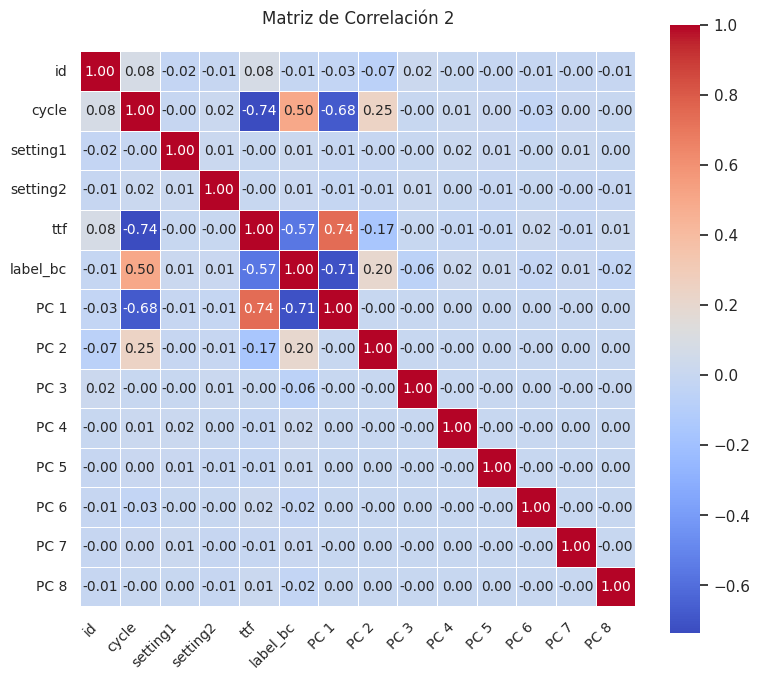

In [92]:
# Cálculo de la correlación entre las variables:
corr2 = dataset_train_no_pca.corr()
# Representamos la matriz de correlación en forma de mapa de calor:
# Configuración del gráfico:
plt.figure(figsize=(8, 8)) # Ajusta el tamaño del gráfico
sns.set(style="white") # Estilo limpio para el fondo
# Mapa de calor de la matriz de correlación:
sns.heatmap(
  corr2, # Matriz de correlación
  annot=True, # Mostrar los valores de correlación
  fmt=".2f", # Formato de los números (2 decimales)
  cmap="coolwarm", # Paleta de colores
  square=True, # Cuadrícula con celdas cuadradas
  cbar_kws={"shrink": 0.8}, # Ajusta el tamaño de la barra de colores
  linewidths=0.5, # Líneas entre celdas
  annot_kws={"size": 10}, # Tamaño de las anotaciones
  )
  # Títulos y etiquetas:
plt.title("Matriz de Correlación 2", fontsize=12, pad=20) #Título con espaciado
plt.xticks(fontsize=10, rotation=45, ha="right") #Etiquetas en el eje X
plt.yticks(fontsize=10, rotation=0) #Etiquetas en el eje Y
# Mostrar el gráfico
plt.tight_layout() # Ajusta el espaciado automáticamente
plt.show()

Pregunta 14: ¿Qué significado tiene esta tabla? ¿Qué sentido tiene dentro del
proceso del PCA?

In [93]:
# Generamos la secuencia de datos:
def gen_sequence(id_df, seq_length, seq_cols):
  df_zeros = pd.DataFrame(np.zeros((seq_length-1,id_df.shape[1])),columns=id_df.columns)
  #id_df = df_zeros.append(id_df,ignore_index=True)
  id_df = pd.concat([df_zeros,id_df],ignore_index=True)
  data_array = id_df[seq_cols].values
  num_elements = data_array.shape[0]
  lstm_array = []

  for start, stop in zip(range(0, num_elements-seq_length),range(seq_length, num_elements)):
    lstm_array.append(data_array[start:stop, :])
  return np.array(lstm_array)

In [94]:
# Generamos la etiqueta label:
def gen_label(id_df, seq_length, seq_cols,label):
  df_zeros = pd.DataFrame(np.zeros((seq_length-1,id_df.shape[1])),columns=id_df.columns)
  #id_df = df_zeros.append(id_df,ignore_index=True)
  id_df = pd.concat([df_zeros,id_df],ignore_index=True)
  data_array = id_df[seq_cols].values
  num_elements = data_array.shape[0]
  y_label=[]
  for start, stop in zip(range(0, num_elements-seq_length),range(seq_length, num_elements)):
    y_label.append(id_df[label][stop])
  return np.array(y_label)

# Fijamos los parámetros seq_leng (longitud de la secuencia
#generada) y seq_cols (valores que se incluirán en cada secuencia,
#variables de entrada)
seq_length = 50
seq_cols = features_col_name

# Generamos X_train
X_train =np.concatenate(list(list(gen_sequence(dataset_train_no_pca[dataset_train_no_pca['id']==id], seq_length, seq_cols)) for id in dataset_train_no_pca['id'].unique()))

# Dimensiones X_train:
print('Dimensiones X_train:', X_train.shape)
# Generamos y_train
y_train =np.concatenate(list(list(gen_label(dataset_train_no_pca[dataset_train_no_pca['id']==id], 50, seq_cols,'label_bc')) for id in dataset_train_no_pca['id'].unique()))
# Dimensiones y_train:
print('Dimensiones y_train:', y_train.shape)

# Generamos y_train
y_train =np.concatenate(list(list(gen_label(dataset_train_no_pca[dataset_train_no_pca['id']==id], 50, seq_cols,'label_bc')) for id in dataset_train_no_pca['id'].unique()))
# Dimensiones y_train:
print('Dimensiones y_train:', y_train.shape)


Dimensiones X_train: (20531, 50, 10)
Dimensiones y_train: (20531,)
Dimensiones y_train: (20531,)


In [95]:
#Generamos X_test
X_test =np.concatenate(list(list(gen_sequence(dataset_test_no_pca[dataset_test_no_pca['id']==id], seq_length, seq_cols)) for id in dataset_test_no_pca['id'].unique()))

#Dimensiones X_test:
print('Dimensiones X_test:', X_test.shape)

# Generamos y_test
y_test =np.concatenate(list(list(gen_label(dataset_test_no_pca[dataset_test_no_pca['id']==id], 50, seq_cols,'label_bc')) for id in dataset_test_no_pca['id'].unique()))

# Dimensiones y_test:
print('Dimensiones y_test:', y_test.shape)

# Importamos librerías necesarias:
from keras.models import Sequential
from keras.layers import Input, LSTM, Dropout, Dense

# Entradas y dimensiones:
nb_features = X_train.shape[2]
timestamp = seq_length

#Configuración de la RN:
model = Sequential()
model.add(Input(shape = (timestamp, nb_features)))
model.add(LSTM(
units = 100,
return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(
units = 50,
return_sequences = False))
model.add(Dropout(0.2))

model.add(Dense(units = 1, activation = 'sigmoid'))
# Paremetrización
model.compile(loss = 'binary_crossentropy', optimizer = 'adam',
metrics = ['accuracy'])
# Mostramos un resumen de la configuración de la red:
model.summary()

Dimensiones X_test: (12996, 50, 10)
Dimensiones y_test: (12996,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50, 100)        │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,651 (291.61 KB)

 Trainable params: 74,651 (291.61 KB)

 Non-trainable params: 0 (0.00 B)

Pregunta 15: Describe la arquitectura de la red neuronal del modelo entrenado.
¿Para qué se emplean este tipo de redes neuronales? ¿Por qué son interesantes
en el problema que se está abordando?

In [96]:
# Entrenamiento del modelo:
model.fit(X_train, y_train, epochs = 10, batch_size = 200,
validation_split = 0.05, verbose = 1,
callbacks = [EarlyStopping(monitor = 'val_loss',
min_delta = 0, patience = 0, verbose = 0, mode = 'auto')])

# Evaluación del modelo:
scores = model.evaluate(X_train, y_train, verbose=1, batch_size =
200)
print('Accurracy: {}'.format(scores[1]))

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 324ms/step - accuracy: 0.8890 - loss: 0.2868 - val_accuracy: 0.9542 - val_loss: 0.1148
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 229ms/step - accuracy: 0.9607 - loss: 0.1026 - val_accuracy: 0.9883 - val_loss: 0.0380
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 249ms/step - accuracy: 0.9656 - loss: 0.0832 - val_accuracy: 0.9757 - val_loss: 0.0565
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9738 - loss: 0.0660
Accurracy: 0.9738444089889526


Pregunta 16: ¿Qué proceso acabamos de llevar a cabo? ¿Qué puedes concluir de
los resultados obtenidos? ¿A qué se debe su duración?

407/407 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step
Accuracy del modelo:  0.9342105263157895


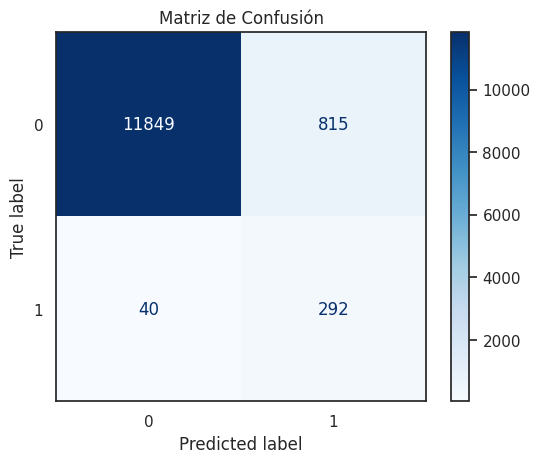

In [97]:
# Predicciones probabilísticas con los datos de evaluación:
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1,0)

#Exactitud del modelo
print('Accuracy del modelo: ',accuracy_score(y_test,y_pred))
# Mostramos la matriz de confusión:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred) # y_test son las etiquetas reales
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión")
plt.show()

**Pregunta 17: ¿Qué puedes concluir de la matriz de confusión obtenida?**

Si evaluamos la diagonal principal (Verdaderos Negativos en la esquina superior izquierda y Verdaderos Positivos en la inferior derecha),ambos valores son notablemente altos en comparación con los falsos positivos y falsos negativos (las otras esquinas), implica que el modelo es altamente robusto distinguiendo un motor estable (0) de uno con fallo inminente en los próximos 30 ciclos (1).

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 335ms/step - accuracy: 0.9784 - loss: 0.0513 - val_accuracy: 0.9572 - val_loss: 0.1318
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 30s 294ms/step - accuracy: 0.9780 - loss: 0.0519 - val_accuracy: 0.9481 - val_loss: 0.1908
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 32s 312ms/step - accuracy: 0.9801 - loss: 0.0456 - val_accuracy: 0.9504 - val_loss: 0.2461
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 298ms/step - accuracy: 0.9808 - loss: 0.0459 - val_accuracy: 0.9510 - val_loss: 0.2436
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step - accuracy: 0.9787 - loss: 0.0494 - val_accuracy: 0.9575 - val_loss: 0.1407
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 346ms/step - accuracy: 0.9813 - loss: 0.0443 - val_accuracy: 0.9454 - val_loss: 0.2747
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 32s 309ms/step - accuracy: 0.9806 - loss: 0.0449 - val_accuracy: 0.9405 - val_loss: 0.2630
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 32s 310ms/step - accuracy: 0.9811 - loss: 0

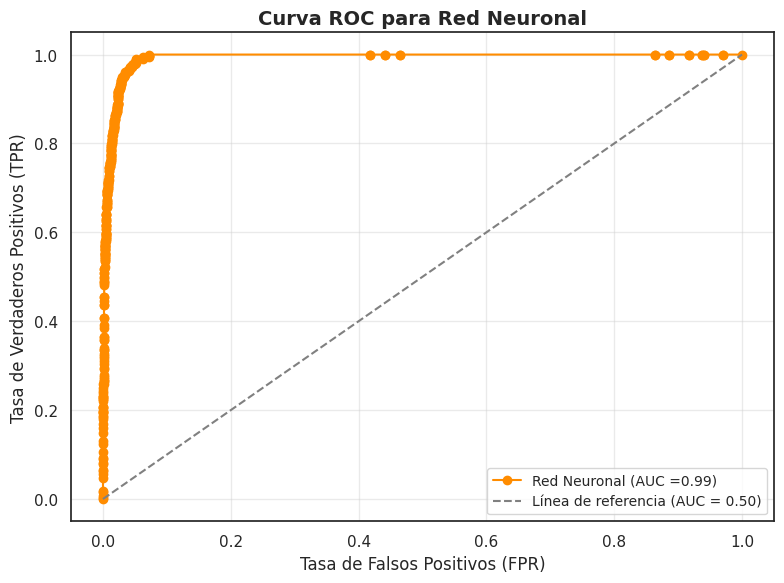

In [105]:
from sklearn.metrics import roc_curve, auc

history = model.fit(X_train, y_train, validation_data = (X_test, y_test),
                    epochs=20, batch_size=200, verbose=1)
y_pred = model.predict(X_test).ravel()

nn_fpr_keras, nn_tpr_keras, nn_thresholds_keras = roc_curve(y_test, y_pred)
auc_keras = auc(nn_fpr_keras, nn_tpr_keras)

# plt.plot(nn_fpr_keras, nn_tpr_keras, marker='.', label='Neural Network (auc = %0.2f)' % auc_keras)

plt.figure(figsize=(8, 6))
plt.plot(nn_fpr_keras, nn_tpr_keras, marker='o', linestyle='-',
color='darkorange', label=f'Red Neuronal (AUC ={auc_keras:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray',
label='Línea de referencia (AUC = 0.50)')
plt.title('Curva ROC para Red Neuronal', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Pregunta 18: ¿Qué significado tiene este tipo de gráfica? ¿Qué puedes concluir
del resultado obtenido para el caso en el que estás trabajando?

In [ ]:
# Probabilidad de que el motor falle en 30 días:
def prob_failure(machine_id):
  machine_df = dataset_test_no_pca[dataset_test_no_pca.id ==
    machine_id]
  machine_test = gen_sequence(machine_df,seq_length,seq_cols)
  m_pred = model.predict(machine_test)
  failure_prob = list(m_pred[-1]*100)[0]
  return failure_prob

# Mostramos ahora la probabilidad de que el motor 16 falle en 30 días:
machine_id = 16
print(f"Probabilidad de que la máquina con ID {machine_id} falle en 30 días: {prob_failure(machine_id):.5f}")

Pregunta 19: ¿Qué significado tiene este resultado? ¿A través de qué técnica lo
estamos obteniendo?

In [104]:
from sklearn.metrics import accuracy_score
#y_pred=model.predict_classes(X_test)
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1,0)
# Visualización de la exactitud:
print('Exactitud (accuracy) del modelo: ', accuracy_score(y_test,y_pred))
# Cálculo del F1-socore:
from sklearn.metrics import f1_score
# Visualización del F1-score con average = macro:
print('F1-score (macro): ', f1_score(y_test, y_pred, average ='macro'))
# Visualización del F1-score con average = micro:
print('F1-score (micro): ', f1_score(y_test, y_pred, average ='micro'))
# Visualización del F1-score con average = weighted
print('F1-score (ponderado): ', f1_score(y_test, y_pred, average = 'weighted'))
# Exactitud equilibrada:
from sklearn.metrics import balanced_accuracy_score
# Visualizamos la exactitud equilibrada:
print('Exactitud equilibrada: ', balanced_accuracy_score(y_test, y_pred))

407/407 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step
Exactitud (accuracy) del modelo:  0.9595260080024623
F1-score (macro):  0.7642341812386599
F1-score (micro):  0.9595260080024623
F1-score (ponderado):  0.9678475400187757
Exactitud equilibrada:  0.9631005068917489


Pregunta 20: ¿Qué significado tienen los diferentes resultados? ¿Cómo permiten
evaluar al modelo obtenido cada uno de ellos?